# Практика 1 Прогнозирование оттока клиентов
Алексеев Николай, ИТ 15-16. Я сравниваю логистическую регрессию, дерево решений и метод ближайших соседей. По заданию выбираю лучшую модель по accuracy. Во второй практике проверю, насколько хорошо она обнаруживает именно уходящих клиентов.
Данные `telecom_churn.csv` взяты из предоставленного комплекта. Здесь `churn` означает уход клиента, а одна строка описывает одного клиента.

In [1]:
from pathlib import Path
import platform
print("Python:", platform.python_version())
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# При запуске из корня проекта или из папки МО находятся одни и те же данные.
BASE = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd() / 'МО'
if not (BASE / 'data').is_dir():
    raise FileNotFoundError('Откройте ноутбук из папки МО или из папки Работы Николая.')
for folder in ['figures', 'results', 'models']:
    (BASE / folder).mkdir(exist_ok=True)
RANDOM_STATE = 42
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})

def save_plot(name):
    # Сохраняю тот же график, который показывается в ноутбуке.
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def save_json(name, data):
    (BASE / 'results' / name).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')

Python: 3.10.20


## Исследование данных
Сначала проверяю размер таблицы, типы столбцов, пропуски и соотношение классов. Телефонный номер является идентификатором, поэтому я исключаю его. Код региона записан числом, но представляет категорию.

In [2]:
df = pd.read_csv(BASE / 'data' / 'telecom_churn.csv')
print('Размер таблицы:', df.shape)
display(df.head())
display(pd.DataFrame({'Тип': df.dtypes.astype(str), 'Пропуски': df.isna().sum()}))
print('Всего пропусков:', int(df.isna().sum().sum()))
display(df['churn'].value_counts().rename(index={False: 'Остался', True: 'Ушёл'}).to_frame('Количество'))
print('Доля ушедших:', round(df['churn'].mean(), 4))

Размер таблицы: (3333, 21)


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


,Тип,Пропуски
state,object,0
account length,int64,0
area code,int64,0
phone number,object,0
international plan,object,0
voice mail plan,object,0
number vmail messages,int64,0
total day minutes,float64,0
total day calls,int64,0
total day charge,float64,0


Всего пропусков: 0


,Количество
churn,
Остался,2850
Ушёл,483


Доля ушедших: 0.1449


## Подготовка и разделение
`X` содержит признаки, `y` содержит правильные ответы. Отделяю 25% клиентов для теста. `stratify=y` сохраняет доли классов. Масштабирование и кодирование обучаются только на train внутри Pipeline. OneHotEncoder создаёт отдельные столбцы для категорий, StandardScaler приводит числовые признаки к сопоставимому масштабу.

Числовые: ['account length', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls']
Категориальные: ['state', 'area code', 'international plan', 'voice mail plan']


,Модель,Accuracy
1,DecisionTreeClassifier,0.904077
2,KNeighborsClassifier,0.878897
0,LogisticRegression,0.868106


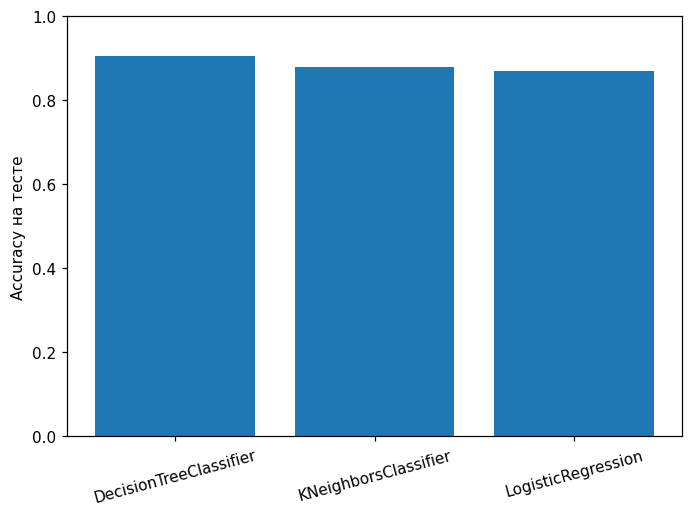

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

X = df.drop(columns=['churn', 'phone number']).copy()
X['area code'] = X['area code'].astype(str)
y = df['churn'].astype(int)
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()
print('Числовые:', num_cols)
print('Категориальные:', cat_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)])
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'KNeighborsClassifier': KNeighborsClassifier()}
fitted = {}
rows = []
for name, estimator in models.items():
    # clone даёт каждой модели собственный экземпляр подготовки данных.
    pipe = Pipeline([('preprocess', clone(preprocess)), ('model', estimator)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    rows.append({'Модель': name, 'Accuracy': accuracy_score(y_test, pipe.predict(X_test))})
results = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
display(results)
results.to_csv(BASE / 'results' / 'practice1.csv', index=False)
plt.bar(results['Модель'], results['Accuracy'])
plt.ylim(0, 1)
plt.ylabel('Accuracy на тесте')
plt.xticks(rotation=15)
save_plot('p1_accuracy.png')

## Матрица ошибок и сохранение результата
Строки матрицы показывают реальные классы, столбцы показывают ответы модели. Верхняя правая ячейка — лояльный клиент ошибочно назван ушедшим (FP). Нижняя левая — ушедший клиент пропущен моделью (FN). Сохраняю победителя и то же разделение для практики 2.

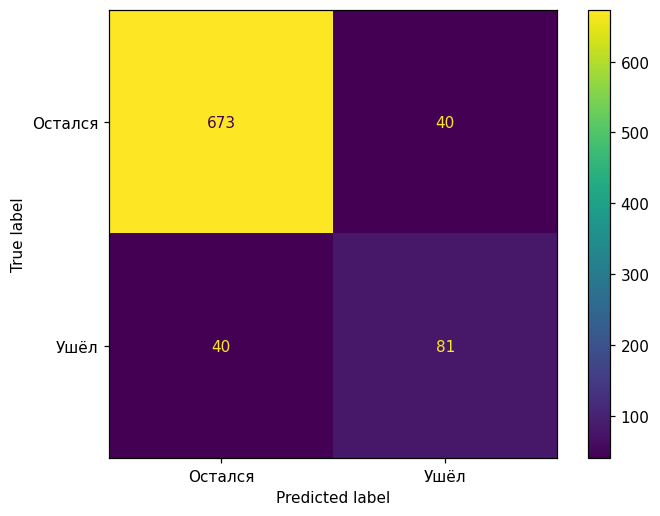

Победитель: DecisionTreeClassifier
Ложные предупреждения FP: 40
Пропущенные ушедшие клиенты FN: 40
Если всегда отвечать «остался», accuracy: 0.8549


In [4]:
from sklearn.metrics import confusion_matrix
best_name = results.iloc[0]['Модель']
best = fitted[best_name]
pred = best.predict(X_test)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['Остался', 'Ушёл']).plot(values_format='d')
save_plot('p1_confusion.png')
print('Победитель:', best_name)
print('Ложные предупреждения FP:', int(cm[0, 1]))
print('Пропущенные ушедшие клиенты FN:', int(cm[1, 0]))
print('Если всегда отвечать «остался», accuracy:', round((y_test == 0).mean(), 4))
with open(BASE / 'models' / 'practice1.pkl', 'wb') as f:
    pickle.dump({'model': best, 'model_name': best_name, 'X_train': X_train,
                 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}, f)
save_json('practice1.json', {'best_model': best_name, 'accuracy': accuracy_score(y_test,pred),
                            'fp': int(cm[0,1]), 'fn': int(cm[1,0])})

## Вывод
Победитель и точные значения приведены в выводе выше. Accuracy подходит для первого сравнения, но при редком оттоке может скрывать пропуски уходящих клиентов. Поэтому во второй практике я дополнительно рассматриваю recall, precision и F1.